### Reference stuff

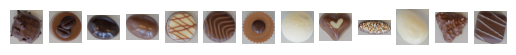

In [12]:
# references
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

def load_bounding_boxes(label_path):
    """Load bounding boxes from a label file."""
    bounding_boxes = []
    with open(label_path, 'r') as f:
        for line in f.readlines():
            parts = line.split()
            cls_id = int(parts[0])  # Class ID
            x_center = float(parts[1])
            y_center = float(parts[2])
            width = float(parts[3])
            height = float(parts[4])
            bounding_boxes.append((cls_id, x_center, y_center, width, height))
    return bounding_boxes

def crop_reference_images(reference_image_dir, ref_labels_dir):
    """Crop reference images based on bounding boxes."""
    reference_images = []
    label_files = [f for f in os.listdir(ref_labels_dir) if f.endswith('.txt')]
    
    for label_file in label_files:
        # Load the corresponding reference image
        image_path = os.path.join(reference_image_dir, label_file.replace('.txt', '.JPG'))
        ref_image = cv2.imread(image_path)
        
        # Load the bounding boxes for this reference image
        label_path = os.path.join(ref_labels_dir, label_file)
        bounding_boxes = load_bounding_boxes(label_path)
        
        # Crop the reference image based on bounding boxes
        for (cls_id, x_center, y_center, width, height) in bounding_boxes:
            # Convert normalized coordinates to pixel values
            h, w, _ = ref_image.shape
            x1 = int((x_center - width / 2) * w)
            y1 = int((y_center - height / 2) * h)
            x2 = int((x_center + width / 2) * w)
            y2 = int((y_center + height / 2) * h)
            
            # Crop the image
            cropped_chocolate = ref_image[y1:y2, x1:x2]
            reference_images.append(cropped_chocolate)
    
    return reference_images

# Example usage
reference_image_dir = 'data/references'
ref_labels_dir = 'data/ref_labels'
reference_images = crop_reference_images(reference_image_dir, ref_labels_dir)

# Display the cropped reference images
for i, ref_img in enumerate(reference_images):
    plt.subplot(1, len(reference_images), i+1)
    plt.imshow(cv2.cvtColor(ref_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
plt.show()


# Compute average width and height of reference chocolates
valid_ref_sizes = set((img.shape[1], img.shape[0]) for img in reference_images)



In [13]:
# Calculate min area from reference images
min_area_from_refs = min(img.shape[0] * img.shape[1] for img in reference_images)
print(f"Minimum reference area: {min_area_from_refs}")

max_area_from_refs = max(img.shape[0] * img.shape[1] for img in reference_images)
print(f"Maximum reference area: {max_area_from_refs}")


for idx, img in enumerate(reference_images):
    h, w = img.shape[:2]
    area = h * w
    print(f"Reference {idx}: {w}x{h} -> Area: {area}")

min_area = 100000

Minimum reference area: 154700
Maximum reference area: 389256
Reference 0: 547x584 -> Area: 319448
Reference 1: 504x498 -> Area: 250992
Reference 2: 472x370 -> Area: 174640
Reference 3: 442x350 -> Area: 154700
Reference 4: 580x571 -> Area: 331180
Reference 5: 550x556 -> Area: 305800
Reference 6: 538x547 -> Area: 294286
Reference 7: 488x493 -> Area: 240584
Reference 8: 662x588 -> Area: 389256
Reference 9: 844x387 -> Area: 326628
Reference 10: 402x446 -> Area: 179292
Reference 11: 610x589 -> Area: 359290
Reference 12: 494x510 -> Area: 251940


### HSV tuning  

In [14]:
# helpers cv2 
import cv2
import numpy as np
import os
import matplotlib.pyplot as plt
import json 

def display_cv2_image(cv_img, title="Image", figsize=(6, 6)):
    """Displays an OpenCV image (BGR) in a Jupyter Notebook using Matplotlib."""
    if cv_img is None:
        print(f"Cannot display image: {title} (image is None)")
        return
    plt.figure(figsize=figsize)
    plt.imshow(cv2.cvtColor(cv_img, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis('off')
    plt.show()

def display_cv2_mask(mask, title="Mask", figsize=(6, 6)):
    """Displays an OpenCV mask (grayscale) in a Jupyter Notebook using Matplotlib."""
    if mask is None:
        print(f"Cannot display mask: {title} (mask is None)")
        return
    plt.figure(figsize=figsize)
    plt.imshow(mask, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

In [15]:
# customized HSV
def empty_callback(value):
    """Empty callback function for trackbars."""
    pass

def tune_hsv_for_image(image_path, initial_lower=None, initial_upper=None):
    """
    Interactive HSV tuner for a single image.
    Allows setting initial trackbar positions.
    Interaction happens in separate OpenCV windows.
    Returns: (lower_bound, upper_bound) or (None, None) if tuning fails or is cancelled.
    """
    image = cv2.imread(image_path)
    if image is None:
        print(f"Error: Could not load image from {image_path}")
        return None, None

    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    
    # Determine a reasonable scale for display, avoiding overly large windows
    max_display_dim = 600 
    h, w = image.shape[:2]
    if h > max_display_dim or w > max_display_dim:
        if h > w:
            display_scale = max_display_dim / h
        else:
            display_scale = max_display_dim / w
    else:
        display_scale = 1.0
    
    scaled_w = int(w * display_scale)
    scaled_h = int(h * display_scale)

    # Trackbar window name (unique per image)
    trackbar_window_name = "HSV Trackbars - " + os.path.basename(image_path)
    # Image display window names
    original_window_name = "Original (Scaled) - " + os.path.basename(image_path)
    mask_window_name = "HSV Mask (Scaled) - " + os.path.basename(image_path)
    result_window_name = "Segmented (Scaled) - " + os.path.basename(image_path)

    final_lower_bound, final_upper_bound = None, None # Initialize

    try:
        cv2.namedWindow(trackbar_window_name)
        cv2.resizeWindow(trackbar_window_name, 600, 300) # Adjust as needed

        cv2.createTrackbar("H_low", trackbar_window_name, 0, 179, empty_callback)
        cv2.createTrackbar("S_low", trackbar_window_name, 0, 255, empty_callback)
        cv2.createTrackbar("V_low", trackbar_window_name, 0, 255, empty_callback)
        cv2.createTrackbar("H_high", trackbar_window_name, 179, 179, empty_callback)
        cv2.createTrackbar("S_high", trackbar_window_name, 255, 255, empty_callback)
        cv2.createTrackbar("V_high", trackbar_window_name, 255, 255, empty_callback)

        if initial_lower is not None:
            cv2.setTrackbarPos("H_low", trackbar_window_name, initial_lower[0])
            cv2.setTrackbarPos("S_low", trackbar_window_name, initial_lower[1])
            cv2.setTrackbarPos("V_low", trackbar_window_name, initial_lower[2])
        if initial_upper is not None:
            cv2.setTrackbarPos("H_high", trackbar_window_name, initial_upper[0])
            cv2.setTrackbarPos("S_high", trackbar_window_name, initial_upper[1])
            cv2.setTrackbarPos("V_high", trackbar_window_name, initial_upper[2])
        else: # Default high to max if not specified
            cv2.setTrackbarPos("H_high", trackbar_window_name, 179)
            cv2.setTrackbarPos("S_high", trackbar_window_name, 255)
            cv2.setTrackbarPos("V_high", trackbar_window_name, 255)

        print(f"\nTuning for: {os.path.basename(image_path)}")
        print("Adjust sliders in the OpenCV window named 'HSV Trackbars...'.")
        print("Press ESC in any of the image display windows to save values and close for this image.")
        print("Press 'q' in any of the image display windows to ABORT tuning for this image.")

        while True:
            h_low = cv2.getTrackbarPos("H_low", trackbar_window_name)
            s_low = cv2.getTrackbarPos("S_low", trackbar_window_name)
            v_low = cv2.getTrackbarPos("V_low", trackbar_window_name)
            h_high = cv2.getTrackbarPos("H_high", trackbar_window_name)
            s_high = cv2.getTrackbarPos("S_high", trackbar_window_name)
            v_high = cv2.getTrackbarPos("V_high", trackbar_window_name)

            current_lower_bound = np.array([h_low, s_low, v_low])
            current_upper_bound = np.array([h_high, s_high, v_high])

            mask = cv2.inRange(hsv_image, current_lower_bound, current_upper_bound)
            result_display_fullres = cv2.bitwise_and(image, image, mask=mask)

            display_image_scaled = cv2.resize(image, (scaled_w, scaled_h))
            display_mask_scaled = cv2.resize(mask, (scaled_w, scaled_h))
            display_result_scaled = cv2.resize(result_display_fullres, (scaled_w, scaled_h))
            
            cv2.imshow(original_window_name, display_image_scaled)
            cv2.imshow(mask_window_name, display_mask_scaled)
            cv2.imshow(result_window_name, display_result_scaled)

            key = cv2.waitKey(30) & 0xFF
            if key == 27:  # ESC key -> Save and exit
                final_lower_bound = current_lower_bound
                final_upper_bound = current_upper_bound
                print(f"  Saved Lower Bound for {os.path.basename(image_path)}: {final_lower_bound.tolist()}")
                print(f"  Saved Upper Bound for {os.path.basename(image_path)}: {final_upper_bound.tolist()}")
                break
            elif key == ord('q'): # 'q' key -> Abort
                print(f"  Tuning aborted for {os.path.basename(image_path)}.")
                final_lower_bound, final_upper_bound = None, None # Ensure None is returned
                break
                
    except cv2.error as e:
        print(f"OpenCV Error during tuning (possibly no display environment): {e}")
        return None, None 
    finally:
        # Clean up all windows associated with this image
        cv2.destroyWindow(original_window_name)
        cv2.destroyWindow(mask_window_name)
        cv2.destroyWindow(result_window_name)
        cv2.destroyWindow(trackbar_window_name)
        cv2.waitKey(1) 

    return final_lower_bound, final_upper_bound

In [16]:
# HSV for the 13 ref chocos
reference_image_folder = reference_image_dir 
chocolate_filenames = ["Amandina.JPG","Arabia.JPG","Comtesse.JPG","Creme_brulee.JPG","Jelly_Black.JPG","Jelly_Milk.JPG","Jelly_White.JPG","Noblesse.JPG","Noir_authentique.JPG","Passion_au_lait.JPG","Stracciatella.JPG","Tentation_noir.JPG","Triangolo.JPG"]

actual_ref_paths = [os.path.join(reference_image_folder, fname) for fname in chocolate_filenames if os.path.exists(os.path.join(reference_image_folder, fname))]
if len(actual_ref_paths) != len(chocolate_filenames):
    print("Warning: Some reference images specified in chocolate_filenames were not found.")
print(f"Found {len(actual_ref_paths)} reference images to tune.")

tuned_ranges_file = 'tuned_hsv_ranges.json'
hsv_ranges_for_chocolates = []

# Try to load previously tuned ranges
if os.path.exists(tuned_ranges_file):
    print(f"Loading tuned ranges from {tuned_ranges_file}...")
    try:
        with open(tuned_ranges_file, 'r') as f:
            loaded_ranges_list = json.load(f)
        hsv_ranges_for_chocolates = [
            {'name': r['name'], 
             'lower': np.array(r['lower'], dtype=np.uint8), 
             'upper': np.array(r['upper'], dtype=np.uint8)} 
            for r in loaded_ranges_list
        ]
        print(f"Successfully loaded {len(hsv_ranges_for_chocolates)} tuned HSV ranges.")
    except Exception as e:
        print(f"Error loading {tuned_ranges_file}: {e}. Will proceed to tuning if needed.")
        hsv_ranges_for_chocolates = []
else:
    print(f"{tuned_ranges_file} not found. You may need to run the tuning process.")

Found 13 reference images to tune.
Loading tuned ranges from tuned_hsv_ranges.json...
Successfully loaded 13 tuned HSV ranges.


In [17]:
# Tuning the images 
FORCE_RETUNE_ALL = False # Set to True to re-tune all images

if not hsv_ranges_for_chocolates or FORCE_RETUNE_ALL:
    print("\n--- Starting Full HSV Tuning Process ---")
    hsv_ranges_for_chocolates = [] # Reset if forcing all
    for img_path in actual_ref_paths:
        # Check if already tuned, unless forcing all
        existing_range = next((r for r in hsv_ranges_for_chocolates if r['name'] == os.path.basename(img_path)), None)
        
        if not FORCE_RETUNE_ALL and existing_range:
            print(f"Skipping tuning for {os.path.basename(img_path)}, already tuned. Set FORCE_RETUNE_ALL=True to override.")
            continue # Skip if already tuned and not forcing

        print(f"\n--- Tuning for image: {img_path} ---")
        # Provide existing values as initial if available
        initial_l = existing_range['lower'] if existing_range else None
        initial_u = existing_range['upper'] if existing_range else None
        
        lower, upper = tune_hsv_for_image(img_path, initial_lower=initial_l, initial_upper=initial_u)
        
        if lower is not None and upper is not None:
            # Remove old entry if re-tuning
            hsv_ranges_for_chocolates = [r for r in hsv_ranges_for_chocolates if r['name'] != os.path.basename(img_path)]
            hsv_ranges_for_chocolates.append({
                'name': os.path.basename(img_path),
                'lower': lower,
                'upper': upper
            })
        print("-" * 40)
    
    # Save the newly tuned ranges
    if hsv_ranges_for_chocolates:
        try:
            with open(tuned_ranges_file, 'w') as f:
                # Convert numpy arrays to lists for JSON serialization
                serializable_ranges = [{'name': r['name'], 'lower': r['lower'].tolist(), 'upper': r['upper'].tolist()} for r in hsv_ranges_for_chocolates]
                json.dump(serializable_ranges, f, indent=4)
            print(f"Successfully saved tuned ranges to {tuned_ranges_file}")
        except Exception as e:
            print(f"Error saving tuned ranges to {tuned_ranges_file}: {e}")
else:
    print("Using previously loaded/defined HSV ranges. Set FORCE_RETUNE_ALL = True in this cell to re-tune.")

print("\n--- Current HSV Ranges ---")
if not hsv_ranges_for_chocolates:
    print("No HSV ranges are currently defined or loaded.")
for item in hsv_ranges_for_chocolates:
    print(f"Name: {item['name']}, Lower: {item['lower'].tolist()}, Upper: {item['upper'].tolist()}")

Using previously loaded/defined HSV ranges. Set FORCE_RETUNE_ALL = True in this cell to re-tune.

--- Current HSV Ranges ---
Name: Amandina.JPG, Lower: [0, 0, 0], Upper: [179, 255, 150]
Name: Arabia.JPG, Lower: [0, 16, 0], Upper: [179, 255, 148]
Name: Comtesse.JPG, Lower: [22, 2, 158], Upper: [85, 255, 255]
Name: Creme_brulee.JPG, Lower: [0, 26, 70], Upper: [179, 255, 255]
Name: Jelly_Black.JPG, Lower: [0, 0, 0], Upper: [179, 255, 165]
Name: Jelly_Milk.JPG, Lower: [0, 1, 36], Upper: [179, 255, 167]
Name: Jelly_White.JPG, Lower: [14, 16, 40], Upper: [179, 255, 255]
Name: Noblesse.JPG, Lower: [0, 28, 0], Upper: [179, 255, 153]
Name: Noir_authentique.JPG, Lower: [0, 19, 0], Upper: [179, 255, 157]
Name: Passion_au_lait.JPG, Lower: [22, 22, 98], Upper: [117, 255, 198]
Name: Stracciatella.JPG, Lower: [0, 14, 0], Upper: [179, 255, 255]
Name: Tentation_noir.JPG, Lower: [0, 22, 0], Upper: [179, 255, 162]
Name: Triangolo.JPG, Lower: [0, 5, 0], Upper: [179, 255, 169]


In [18]:
# import pickle
# with open("choco_hsv.pkl", "wb") as f:
#     pickle.dump(hsv_ranges_for_chocolates, f)

# with open("choco_thresholds.pkl", "rb") as f:
#     choco_thresholds = pickle.load(f)


### Segmentation

In [46]:
def segment_chocolates_from_tuned_ranges(image, all_hsv_ranges,
                                         blur_ksize=5,
                                         morph_close_kernel_size=(5,5), morph_close_iter=2,
                                         morph_open_kernel_size=(3,3), morph_open_iter=2,
                                         min_area_contour=300,
                                         use_watershed_if_needed=False,
                                         watershed_erode_iter=1, watershed_dilate_iter=3,
                                         resize_dim=(64,64)):
    """
    Segments chocolates from an image using a list of pre-tuned HSV ranges.
    (Args and Returns same as previously defined)
    """
    segments = []
    if image is None:
        print("Error: Input image is None for segmentation.")
        return segments, None # Return empty segments and None for mask
    
    original_image_for_cropping = image.copy()
    
    if blur_ksize % 2 == 0: # Ensure blur_ksize is odd
        blur_ksize += 1
        
    hsv_image_full = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    blurred_hsv = cv2.GaussianBlur(hsv_image_full, (blur_ksize, blur_ksize), 0)

    combined_color_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    if not all_hsv_ranges:
        print("Warning: No HSV ranges provided to segmentation function.")
    for hsv_set in all_hsv_ranges:
        if 'lower' not in hsv_set or 'upper' not in hsv_set:
            print(f"Warning: Invalid HSV set skipped: {hsv_set.get('name', 'Unknown')}")
            continue
        lower_b = hsv_set['lower']
        upper_b = hsv_set['upper']
        current_mask = cv2.inRange(blurred_hsv, lower_b, upper_b)
        combined_color_mask = cv2.bitwise_or(combined_color_mask, current_mask)

    kernel_close = np.ones(morph_close_kernel_size, np.uint8)
    closed_mask = cv2.morphologyEx(combined_color_mask, cv2.MORPH_CLOSE, kernel_close, iterations=morph_close_iter)
    
    kernel_open = np.ones(morph_open_kernel_size, np.uint8)
    opened_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel_open, iterations=morph_open_iter)

    final_mask_for_contours = opened_mask.copy() # Default mask

    if use_watershed_if_needed:
        pre_ws_contours, _ = cv2.findContours(opened_mask.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if len(pre_ws_contours) > 0:
            sure_bg = cv2.dilate(opened_mask, kernel_open, iterations=watershed_dilate_iter)
            dist_transform = cv2.distanceTransform(opened_mask, cv2.DIST_L2, 5)
            # Threshold distance transform to get sure foreground. Adjust threshold (e.g., 0.5 * dist_transform.max())
            ret, sure_fg = cv2.threshold(dist_transform, 0.2 * dist_transform.max(), 255, 0) # Threshold needs tuning
            sure_fg = np.uint8(sure_fg)
            unknown = cv2.subtract(sure_bg, sure_fg)
            
            ret, markers = cv2.connectedComponents(sure_fg)
            if ret > 1: # More than just background
                markers = markers + 1
                markers[unknown == 255] = 0
                
                # Use original BGR image for watershed coloring to guide boundaries
                img_for_watershed = original_image_for_cropping.copy() 
                cv2.watershed(img_for_watershed, markers)
                
                # Create a new mask from watershed results, excluding boundaries (-1) and background (1)
                watershed_result_mask = np.zeros_like(opened_mask, dtype=np.uint8)
                for label in np.unique(markers):
                    if label == -1 or label == 0 or label == 1: # Boundary, unknown, or background
                        continue
                    watershed_result_mask[markers == label] = 255
                
                # Optional: Post-process watershed_result_mask (e.g., small opening)
                # kernel_ws_post = np.ones((3,3), np.uint8)
                # watershed_result_mask = cv2.morphologyEx(watershed_result_mask, cv2.MORPH_OPEN, kernel_ws_post)

                final_mask_for_contours = watershed_result_mask # Use this mask for contours
                # print("Using watershed-derived mask for contours.")
            # else: print("Not enough distinct components for watershed markers, falling back.")
        # else: print("No preliminary contours for watershed, falling back.")


    contours, _ = cv2.findContours(final_mask_for_contours.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    for cnt in contours:
        area = cv2.contourArea(cnt)
        if area < min_area_contour:
            continue
        
        x, y, w, h = cv2.boundingRect(cnt)
        crop = original_image_for_cropping[y:y+h, x:x+w]
        if crop.size > 0:
            segments.append(cv2.resize(crop, resize_dim))
            
    return segments, final_mask_for_contours # Return segments and the final mask used

In [34]:
# second version with less invasion of masks
import cv2
import numpy as np

def segment_chocolates_from_tuned_ranges(image, all_hsv_ranges,
                                         blur_ksize=5,
                                         morph_close_kernel_size=(5,5), morph_close_iter=2,
                                         morph_open_kernel_size=(3,3), morph_open_iter=2,
                                         min_area_contour=300, 
                                         use_watershed_if_needed=False,
                                         watershed_erode_iter=1, # Iterations for eroding before dist transform
                                         watershed_dilate_iter=3, # Iterations for sure_bg dilation
                                         watershed_fg_thresh_ratio=0.4, # Ratio for dist transform threshold (0.1-0.7 typical)
                                         resize_dim=(120,120)):
    """
    Segments chocolates from an image using a list of pre-tuned HSV ranges,
    with improved watershed for separating touching objects.
    """
    segments = []
    if image is None:
        print("Error: Input image is None for segmentation.")
        return segments, None

    original_image_for_cropping = image.copy()

    if blur_ksize % 2 == 0: # Ensure blur_ksize is odd
        blur_ksize += 1

    hsv_image_full = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    blurred_hsv = cv2.GaussianBlur(hsv_image_full, (blur_ksize, blur_ksize), 0)

    combined_color_mask = np.zeros(image.shape[:2], dtype=np.uint8)
    if not all_hsv_ranges:
        print("Warning: No HSV ranges provided to segmentation function.")
    for hsv_set in all_hsv_ranges:
        if not isinstance(hsv_set, dict) or 'lower' not in hsv_set or 'upper' not in hsv_set:
            print(f"Warning: Invalid HSV set skipped (must be dict with 'lower'/'upper'): {hsv_set}")
            continue
        lower_b = np.array(hsv_set['lower'])
        upper_b = np.array(hsv_set['upper'])
        current_mask = cv2.inRange(blurred_hsv, lower_b, upper_b)
        combined_color_mask = cv2.bitwise_or(combined_color_mask, current_mask)

    kernel_close = np.ones(morph_close_kernel_size, np.uint8)
    closed_mask = cv2.morphologyEx(combined_color_mask, cv2.MORPH_CLOSE, kernel_close, iterations=morph_close_iter)

    kernel_open = np.ones(morph_open_kernel_size, np.uint8)
    opened_mask = cv2.morphologyEx(closed_mask, cv2.MORPH_OPEN, kernel_open, iterations=morph_open_iter)

    final_mask_for_contours = opened_mask.copy() # Default mask

    if use_watershed_if_needed and cv2.countNonZero(opened_mask) > 0:
        # print("Attempting watershed segmentation...")
        mask_for_watershed_input = opened_mask.copy()

        # 1. Sure Background
        kernel_ws_bg_dilate = np.ones((3,3), np.uint8) # Consistent kernel for BG dilation
        sure_bg = cv2.dilate(mask_for_watershed_input, kernel_ws_bg_dilate, iterations=watershed_dilate_iter)

        # 2. Sure Foreground
        # Erode the mask to help separate touching objects before distance transform
        kernel_ws_fg_erode = np.ones((3,3), np.uint8) # Consistent kernel for FG erosion
        eroded_for_fg = cv2.erode(mask_for_watershed_input, kernel_ws_fg_erode, iterations=watershed_erode_iter)

        dist_transform = cv2.distanceTransform(eroded_for_fg, cv2.DIST_L2, 5)

        # Threshold the distance transform to get sure foreground.
        # watershed_fg_thresh_ratio is critical: higher values -> smaller, more separated seeds.
        if dist_transform.max() > 0:
            fg_threshold_value = watershed_fg_thresh_ratio * dist_transform.max()
            ret, sure_fg = cv2.threshold(dist_transform, fg_threshold_value, 255, 0)
            sure_fg = np.uint8(sure_fg)
        else:
            sure_fg = np.zeros_like(eroded_for_fg, dtype=np.uint8) # Empty sure_fg if dist_transform is all zero

        # 3. Unknown Region
        unknown = cv2.subtract(sure_bg, sure_fg)

        # 4. Create Markers
        # connectedComponents returns N labels (0 to N-1), 0 is background. ret is N.
        ret, markers = cv2.connectedComponents(sure_fg)

        # If ret <= 1, it means no foreground objects (or only background) were found in sure_fg.
        if ret <= 1:
            # print("Watershed: Not enough distinct foreground components for markers. Falling back to non-watershed mask.")
            pass # final_mask_for_contours remains opened_mask
        else:
            # Add one to all labels so that sure background (originally 0 in markers) is not 0, but 1
            markers = markers + 1
            # Mark the region of unknown (where watershed will draw boundaries) with zero
            markers[unknown == 255] = 0

            # Apply Watershed
            img_for_watershed = original_image_for_cropping.copy() # Use BGR image for watershed
            cv2.watershed(img_for_watershed, markers)

            # Create a new binary mask from the watershed result
            # Watershed labels boundaries with -1. Background is 1 (due to markers+1). Objects are > 1.
            watershed_result_mask = np.zeros_like(opened_mask, dtype=np.uint8)
            unique_labels_in_result = np.unique(markers)
            for label in unique_labels_in_result:
                # Exclude watershed boundaries (-1), unknown regions that became 0, and sure background (1)
                if label == -1 or label == 0 or label == 1:
                    continue
                watershed_result_mask[markers == label] = 255

            # Optional: Post-process watershed_result_mask (e.g., small opening to remove tiny artifacts)
            # kernel_ws_post = np.ones((3,3), np.uint8)
            # watershed_result_mask = cv2.morphologyEx(watershed_result_mask, cv2.MORPH_OPEN, kernel_ws_post, iterations=1)
            
            if cv2.countNonZero(watershed_result_mask) > 0: # Ensure watershed produced some result
                final_mask_for_contours = watershed_result_mask
                # print("Using watershed-derived mask for contours.")
            # else:
                # print("Watershed produced an empty mask. Falling back to non-watershed mask.")


    contours, _ = cv2.findContours(final_mask_for_contours.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    for cnt in contours:
        area = cv2.contourArea(cnt)
        # min_area_contour applies to the contours found in the original scale mask
        # BEFORE they are cropped and resized. You might need to adjust this
        # if your reference areas are for the original scale.
        # However, the current logic is fine if min_area_contour is meant for small noise filtering.
        if area < min_area_contour: # This min_area_contour is at original image scale
            continue

        x, y, w, h = cv2.boundingRect(cnt)
        crop = original_image_for_cropping[y:y+h, x:x+w]
        
        # Ensure the crop is not empty and has valid dimensions before resizing
        if crop.size > 0 and w > 0 and h > 0:
            if resize_dim is not None and isinstance(resize_dim, tuple) and len(resize_dim) == 2:
                segments.append(cv2.resize(crop, resize_dim, interpolation=cv2.INTER_AREA))
            else:
                segments.append(crop) # Append unresized if resize_dim is None or invalid
        # else:
            # print(f"Warning: Empty or invalid crop skipped. x:{x} y:{y} w:{w} h:{h} area:{area}")


    return segments, final_mask_for_contours


In [41]:
def shadow_remove(img):
    rgb_planes = cv2.split(img)
    result_norm_planes = []
    for plane in rgb_planes:
        dilated_img = cv2.dilate(plane, np.ones((70,70), np.uint8))
        bg_img = cv2.medianBlur(dilated_img, 21)
        diff_img = 255 - cv2.absdiff(plane, bg_img)
        norm_img = cv2.normalize(diff_img,None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX, dtype=cv2.CV_8UC1)
        result_norm_planes.append(norm_img)
    shadowremov = cv2.merge(result_norm_planes)
    return shadowremov

Using test image: data/test/L1000762.JPG

--- Segmenting Test Image ---


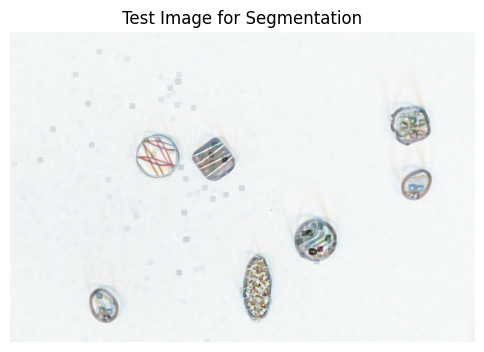


Found 102 potential chocolate segments.


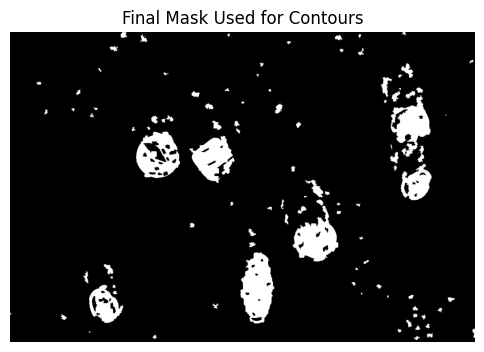

Segmented image (on black background) successfully saved as segmented_regions_on_black_background.png
Displaying found segments:


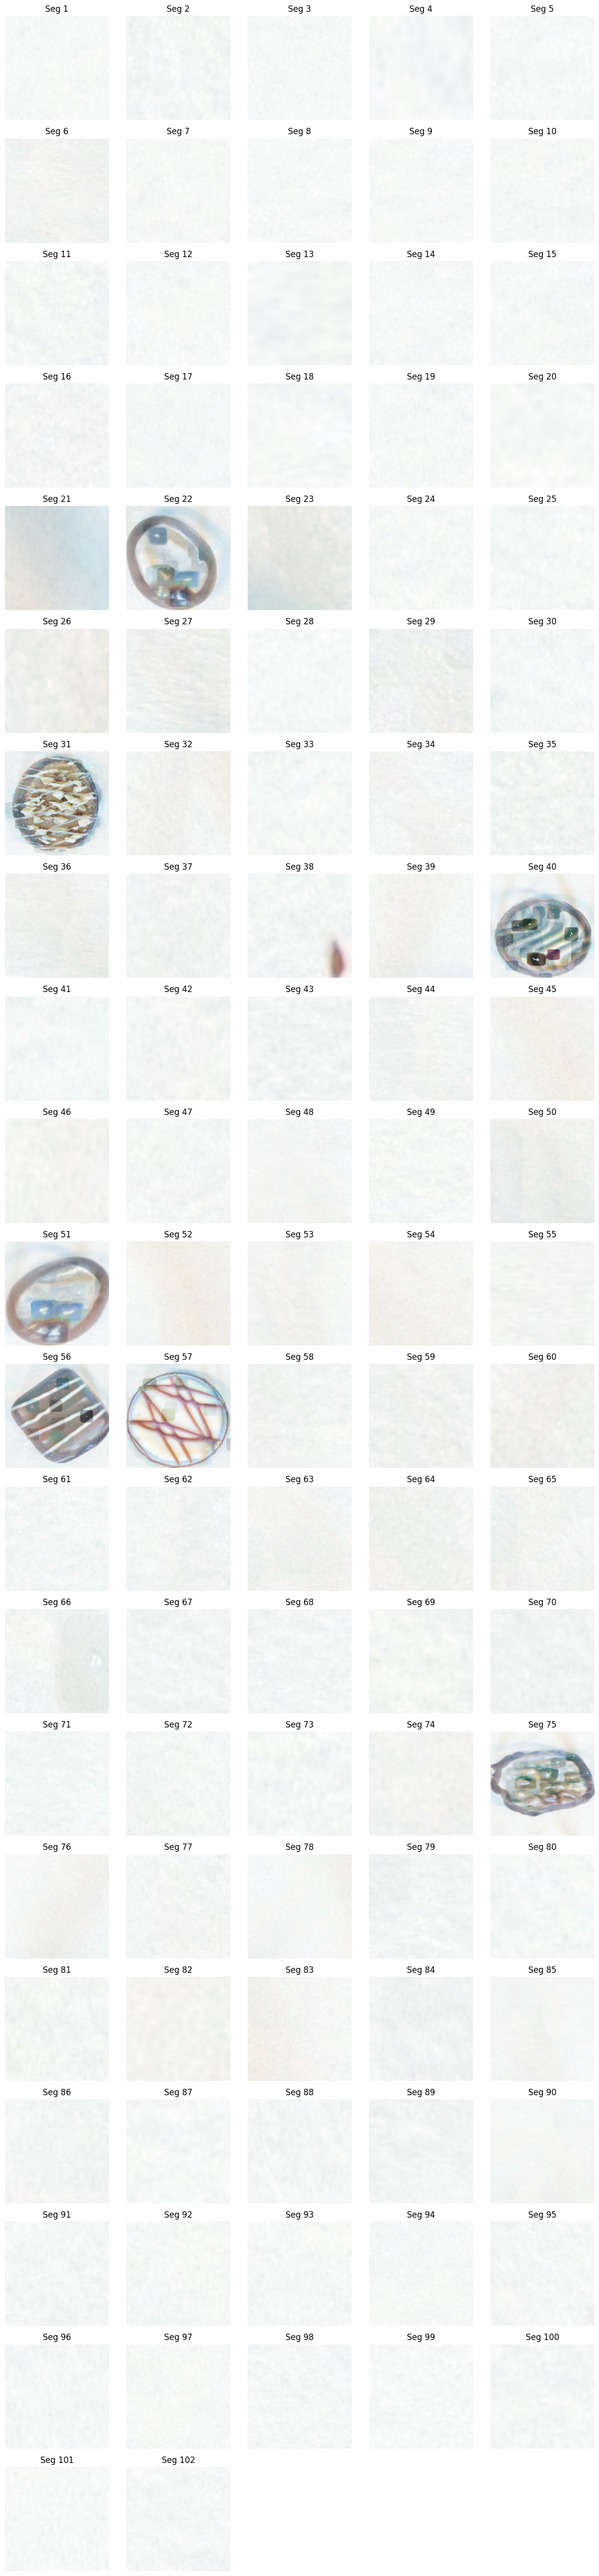

In [49]:
import pickle 
with open("choco_hsv.pkl", "rb") as f:
    hsv_ranges_for_chocolates = pickle.load(f)

test_image_path = "data/test/L1000762.JPG" 
# test_image_path ="data/test/test4.png"


test_image_loaded_original = cv2.imread(test_image_path)
test_image_loaded_original = shadow_remove(test_image_loaded_original)


print(f"Using test image: {test_image_path}")

print("\n--- Segmenting Test Image ---")
display_cv2_image(test_image_loaded_original, title="Test Image for Segmentation")

final_segmentation_mask = None
extracted_segments = []

if not hsv_ranges_for_chocolates:
    print("CRITICAL: HSV ranges not available. Cannot segment.")
else:
    extracted_segments, final_segmentation_mask = segment_chocolates_from_tuned_ranges(
        test_image_loaded_original.copy(),
        hsv_ranges_for_chocolates,
        blur_ksize=5,
        min_area_contour=200,
        use_watershed_if_needed=True,
        watershed_erode_iter=2, watershed_dilate_iter=2,
        resize_dim=NEW_CLASSIFIER_INPUT_RESOLUTION
    )

    print(f"\nFound {len(extracted_segments)} potential chocolate segments.")

    if final_segmentation_mask is not None:
        display_cv2_mask(final_segmentation_mask, title="Final Mask Used for Contours")

     # >>>>> START OF SAVE <<<<<
        if test_image_loaded_original is not None: 
            if len(final_segmentation_mask.shape) == 3:
                gray_mask_for_bitwise = cv2.cvtColor(final_segmentation_mask, cv2.COLOR_BGR2GRAY)
                _, binary_mask_for_bitwise = cv2.threshold(gray_mask_for_bitwise, 1, 255, cv2.THRESH_BINARY)
            elif len(final_segmentation_mask.shape) == 2:
                _, binary_mask_for_bitwise = cv2.threshold(final_segmentation_mask, 1, 255, cv2.THRESH_BINARY)
            else:
                print("Error: final_segmentation_mask has an unexpected number of dimensions.")
                binary_mask_for_bitwise = None

            if binary_mask_for_bitwise is not None:
                if test_image_loaded_original.shape[:2] == binary_mask_for_bitwise.shape:
                    segmented_on_black = cv2.bitwise_and(
                        test_image_loaded_original,
                        test_image_loaded_original,
                        mask=binary_mask_for_bitwise
                    )
                    segmented_black_bg_filename = "segmented_regions_on_black_background.png"
                    try:
                        success_save = cv2.imwrite(segmented_black_bg_filename, segmented_on_black)
                        if success_save:
                            print(f"Segmented image (on black background) successfully saved as {segmented_black_bg_filename}")
                        else:
                            print(f"Error: Failed to save segmented image (on black background) to {segmented_black_bg_filename}")
                    except Exception as e:
                        print(f"An exception occurred while saving the segmented image (on black background): {e}")
                else:
                    print(f"Error: Dimension mismatch between original image ({test_image_loaded_original.shape[:2]}) "
                          f"and binary mask ({binary_mask_for_bitwise.shape}). Cannot perform bitwise_and.")
        else:
            print("Skipping save of segmented part: test_image_loaded_original is not available.")
        # >>>>> END OF SAVE <<<<<


    if extracted_segments:
        print("Displaying found segments:")
        num_segments = len(extracted_segments)
        cols = 5
        rows = (num_segments + cols - 1) // cols
        if num_segments > 0 and rows == 0: rows = 1
            
        if rows > 0:
            fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.5, rows * 2.5))
            if num_segments == 1 and cols > 1 :
                 axes = np.array([axes])
            axes = axes.flatten()

            for i, seg_img in enumerate(extracted_segments):
                if i < len(axes):
                    axes[i].imshow(cv2.cvtColor(seg_img, cv2.COLOR_BGR2RGB))
                    axes[i].set_title(f"Seg {i+1}")
                    axes[i].axis('off')
            
            for j in range(num_segments, len(axes)):
                if j < len(axes):
                    fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()
        else:
            print("No subplots to create.")
    else:
        print("No segments found.")

In [ ]:
# classify with new res one

import numpy as np
print(f"\n--- Predictions for {len(extracted_segments)} Segments ---")
for i, seg in enumerate(extracted_segments):
    features = extract_features(seg)
    all_probabilities_for_segment = clf_new_resolution.predict_proba([features])[0]
    predicted_class_index = np.argmax(all_probabilities_for_segment)
    confidence_for_predicted_class = all_probabilities_for_segment[predicted_class_index]
    predicted_label_name = label_mapping.get(predicted_class_index, f"Unknown_ID_{predicted_class_index}")
    print(f"Segment {i+1}: Predicted as {predicted_label_name} (Confidence: {confidence_for_predicted_class:.2f})")

    # all probabilities for debugging
    # print(f"  All probabilities: {all_probabilities_for_segment}")
    # for class_idx, prob_val in enumerate(all_probabilities_for_segment):
    #     class_name_debug = label_mapping.get(class_idx, f"Unknown_ID_{class_idx}")
    #     print(f"    {class_name_debug}: {prob_val:.3f}")


--- Predictions for 7 Segments ---
Segment 1: Predicted as Comtesse (Confidence: 0.29)
Segment 2: Predicted as Stracciatella (Confidence: 0.14)
Segment 3: Predicted as Triangolo (Confidence: 0.15)
Segment 4: Predicted as Tentation_noir (Confidence: 0.15)
Segment 5: Predicted as Amandina (Confidence: 0.18)
Segment 6: Predicted as Jelly_white (Confidence: 0.24)
Segment 7: Predicted as Jelly_white (Confidence: 0.38)


In [25]:
# classify with the other one
predictions_output = []
for seg in extracted_segments: # These segments must be resized to NEW_CLASSIFIER_INPUT_RESOLUTION
    try:
        features = extract_features_enhanced(seg) # 'seg' should be BGR and correct size
        proba = best_rf_model.predict_proba([features])[0]
        pred_idx = np.argmax(proba)
        confidence = proba[pred_idx]
        label = label_mapping.get(pred_idx, "Unknown")
        print(f"Predicted: {label} (Confidence: {confidence:.2f})")
        predictions_output.append({'label': label, 'confidence': confidence, 'image': seg})
    except Exception as e:
        print(f"Error predicting on a segment: {e}")

Predicted: Stracciatella (Confidence: 0.15)
Predicted: Jelly_white (Confidence: 0.22)
Predicted: Comtesse (Confidence: 0.41)
Predicted: Jelly_white (Confidence: 0.25)
Predicted: Jelly_white (Confidence: 0.25)
Predicted: Jelly_white (Confidence: 0.51)


### Stupidity

In [63]:
# helpers

def is_overlap(x1, y1, w1, h1, x2, y2, w2, h2, overlap_thresh=0.5):
    """
    Check if two bounding boxes overlap more than a given threshold.
    """
    # Calculate intersection
    x1_max, y1_max = x1 + w1, y1 + h1
    x2_max, y2_max = x2 + w2, y2 + h2
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)

    # No intersection
    if inter_x1 >= inter_x2 or inter_y1 >= inter_y2:
        return False

    # Calculate intersection area and union area
    intersection_area = (inter_x2 - inter_x1) * (inter_y2 - inter_y1)
    area1 = w1 * h1
    area2 = w2 * h2
    union_area = area1 + area2 - intersection_area

    # Calculate overlap ratio
    overlap = intersection_area / union_area
    return overlap > overlap_thresh

import numpy as np
import cv2

def filter_low_variation_segments(segments, std_threshold=10):
    """
    Remove segments with very low color variation (nearly uniform color).
    
    Parameters:
        segments (list of np.array): List of image segments (e.g., 64x64x3).
        std_threshold (float): Standard deviation threshold below which segments are discarded.

    Returns:
        List of filtered segments.
    """
    filtered = []
    for seg in segments:
        # Compute standard deviation across all color channels
        stddev = np.std(seg)
        if stddev > std_threshold:
            filtered.append(seg)
    return filtered


In [64]:
# other way, sometimes catches white chocos
def segment_chocolates_v2(image, blur_ksize=5, min_area=500, method='adaptive'):
    segments = []
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (blur_ksize, blur_ksize), 0)

    if method == 'adaptive':
        thresh = cv2.adaptiveThreshold(blurred, 255,
                                       cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                       cv2.THRESH_BINARY_INV,
                                       11, 2)
    else:
        _, thresh = cv2.threshold(blurred, 0, 255,
                                  cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    # Apply morphological closing to fill small holes or gaps
    kernel = np.ones((5, 5), np.uint8)  # Slightly larger kernel for closing
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_CLOSE, kernel, iterations=2)

    # Optional: Apply morphological opening to remove small blobs
    kernel_open = np.ones((5, 5), np.uint8)
    thresh = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel_open)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    # Apply Non-Maximum Suppression or bounding box merging
    processed_bboxes = []
    for cnt in contours:
        if cv2.contourArea(cnt) < min_area:
            continue
        x, y, w, h = cv2.boundingRect(cnt)
        
        # Merge bounding boxes (simple approach)
        merged = False
        for (bx, by, bw, bh) in processed_bboxes:
            if is_overlap(x, y, w, h, bx, by, bw, bh):
                # Merge bounding boxes: take the outer bounding box
                new_x = min(x, bx)
                new_y = min(y, by)
                new_w = max(x + w, bx + bw) - new_x
                new_h = max(y + h, by + bh) - new_y
                processed_bboxes.remove((bx, by, bw, bh))
                processed_bboxes.append((new_x, new_y, new_w, new_h))
                merged = True
                break

        if not merged:
            processed_bboxes.append((x, y, w, h))

    # Extract segments from the merged bounding boxes
    for (x, y, w, h) in processed_bboxes:
        crop = image[y:y+h, x:x+w]
        if crop.size > 0:
            crop_resized = cv2.resize(crop, (64, 64))
            segments.append(crop_resized)

    return segments

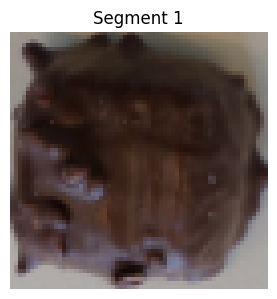

In [65]:
# ALRIGHTY
import matplotlib.pyplot as plt
import cv2

# test_image_path = "data/test/L1000764.JPG"
# test_image = cv2.imread(test_image_path)

test_image = extracted_segments[2]

def show_segments(segments):
    """
    Display filtered image segments using Matplotlib, 2 per figure.
    """
    for i in range(0, len(segments), 2):
        plt.figure(figsize=(6, 3))
        for j in range(2):
            if i + j >= len(segments):
                break
            plt.subplot(1, 2, j + 1)
            plt.imshow(cv2.cvtColor(segments[i + j], cv2.COLOR_BGR2RGB))
            plt.axis('off')
            plt.title(f'Segment {i + j + 1}')
        plt.tight_layout()
        plt.show()

# Extract valid sizes from reference images
valid_ref_sizes = set((img.shape[1], img.shape[0]) for img in reference_images)

# Segment using valid reference sizes and filter
# segments = segment_chocolates(test_image, valid_ref_sizes, tolerance=0.1)
# segments = segment_chocolates(test_image)
segments_stupidity = segment_chocolates_v2(test_image)
# filtered_segments = filter_low_variation_segments(segments, std_threshold=10)

# Show results
show_segments(segments_stupidity)
# filtered_segments = filter_low_variation_segments(segments, std_threshold=10)
# print("filtered")
# show_segments(filtered_segments)



In [66]:
for seg in segments_stupidity:
    features = extract_features(seg)
    proba = clf.predict_proba([features])[0]  
    prediction = np.argmax(proba)            
    confidence = proba[prediction]          
    label = label_mapping[prediction]
    print(f"{label} ({confidence:.2f})")

Jelly_black (0.22)
